## Experiment 6: Simple Fused CUDA Kernel



Objective

The objective of this experiment is to study kernel fusion by combining multiple simple tensor operations into a single custom CUDA kernel.

The target computation will be:

$$
y_i = ReLU(ax_i + b)
$$

The operation will first be implemented using separate PyTorch operations:

```python
y = torch.relu(a * x + b)
```

and then using one custom CUDA kernel that performs the multiply, addition, and ReLU operation during a single pass over the input data.

The experiment will compare:

* Correctness of the fused CUDA implementation.
* Execution latency.
* Number of kernel launches.
* Intermediate tensor creation.
* Global-memory reads and writes.
* Effective memory traffic.
* The effect of fusion on arithmetic intensity.

The purpose of the experiment is to demonstrate how custom CUDA kernels can improve the performance of simple memory-bound workloads by avoiding unnecessary intermediate tensors and reducing repeated transfers of intermediate results through global memory.


## Implementation

In [1]:
!nvidia-smi


Sun Sep 13 23:23:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ninja


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 17.1 MB/s eta 0:00:00


In [5]:
#importing libraries
import torch # standard torch operations
from torch.utils.cpp_extension import load_inline # loading inline C++/CUDA code
import pandas as pd # data manipulation
import time # timing operations
from matplotlib import pyplot as plt # plotting
from matplotlib import __version__ as matplotlib_version
print("Library Versions:")
print(f"PyTorch: {torch.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {matplotlib_version}")



Library Versions:
PyTorch: 2.11.0+cu128
Pandas: 2.2.3
Matplotlib: 3.10.0


In [57]:
cpp_code="""
#include <torch/extension.h>

torch::Tensor fused_relu_forward(
    torch::Tensor x,
    torch::Tensor a,
    torch::Tensor b,
    int block_size
);
"""

cuda_code="""
#include <torch/extension.h>
#include <cstdint>
#include <c10/cuda/CUDAException.h>
#include <cmath>

__global__ void fused_relu_forward_kernel(
    const float* x,
    const float* a,
    const float* b,
    float* y,
    int n
){
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    if (idx < n){
        float z = a[idx] * x[idx] + b[idx];
        y[idx] = fmaxf(0.0f, z);
    }
}

torch::Tensor fused_relu_forward(
    torch::Tensor x,
    torch::Tensor a,
    torch::Tensor b,
    int block_size
){
    TORCH_CHECK(x.is_cuda(), "x must be on GPU");
    TORCH_CHECK(a.is_cuda(), "a must be on GPU");
    TORCH_CHECK(b.is_cuda(), "b must be on GPU");

    TORCH_CHECK(x.is_contiguous(), "x must be contiguous");
    TORCH_CHECK(a.is_contiguous(), "a must be contiguous");
    TORCH_CHECK(b.is_contiguous(), "b must be contiguous");

    TORCH_CHECK(x.scalar_type() == torch::kFloat32, "x must be float32");
    TORCH_CHECK(a.scalar_type() == torch::kFloat32, "a must be float32");
    TORCH_CHECK(b.scalar_type() == torch::kFloat32, "b must be float32");

    TORCH_CHECK(
        x.numel() == a.numel() && x.numel() == b.numel(),
        "x, a, and b must contain the same number of elements"
    );

    int n = x.numel();

    torch::Tensor y = torch::empty_like(x);

    int num_blocks = (n + block_size - 1) / block_size;

    fused_relu_forward_kernel<<<num_blocks, block_size>>>(
        x.data_ptr<float>(),
        a.data_ptr<float>(),
        b.data_ptr<float>(),
        y.data_ptr<float>(),
        n
    );

    C10_CUDA_KERNEL_LAUNCH_CHECK();

    return y;
} 

"""

In [58]:
def torch_relu_forward(x, a, b):
    return torch.relu(a * x + b)


### Profiling

In [59]:
def write_script_to_file(script, filename):
    with open(filename, "w") as f:
        f.write(script)


In [66]:
profiler_script = """
import torch
import argparse
from torch.utils.cpp_extension import load_inline


parser = argparse.ArgumentParser(description="Profiling script for ReLU forward pass")
parser.add_argument("--input-size", type=int, default=1024, help="Input size")
parser.add_argument("--block-size", type=int, default=256, help="Block size")
parser.add_argument("--kernel", type=str, choices=["fused", "torch"], default="fused", help="Kernel to use")
args = parser.parse_args()

def read_file(filename):
    with open(filename, "r") as f:
        return f.read()

cpp_code=read_file("./relu_forward.cpp")
cuda_code=read_file("./relu_forward.cu")

cuda_module = load_inline(
    name="relu_cuda_v3",
    cpp_sources = cpp_code,
    cuda_sources = cuda_code,
    functions = ["fused_relu_forward"],
    extra_cflags = ["-O3"],
    extra_cuda_cflags = ["-O3"],
    verbose = True
)

def benchmark(input_size, kernel, block_size):
    x = torch.randn(input_size, device="cuda")
    a = torch.randn(input_size, device="cuda")
    b = torch.randn(input_size, device="cuda")
    y = torch.zeros(input_size, device="cuda")
    # warmup
    for _ in range(10):
        y = cuda_module.fused_relu_forward(x, a, b, block_size)
    # benchmark
    if kernel == "fused":
        start_time = torch.cuda.Event(enable_timing=True)
        end_time = torch.cuda.Event(enable_timing=True)
        start_time.record()
        y = cuda_module.fused_relu_forward(x, a, b, block_size)
        end_time.record()
        torch.cuda.synchronize()
    elif kernel == "torch":
        y = torch.relu(a * x + b)
    return y

if __name__ == "__main__":
    benchmark(input_size=args.input_size, kernel=args.kernel, block_size=args.block_size)
"""


In [67]:
write_script_to_file(cpp_code, "relu_forward.cpp")
write_script_to_file(cuda_code, "relu_forward.cu")
write_script_to_file(profiler_script, "relu_forward_profiler.py")

Now we want to check which metrics within ncu can we look for:

- Global Memeory Transfer (Read/Write)
- Shared Memory Usage (l1tex)

In [68]:
!ncu \
    --metrics "dram__bytes_read,dram__bytes_write,l1tex__t_bytes_pipe_lsu_mem_global_op_ld,l1tex__t_bytes_pipe_lsu_mem_global_op_st,l1tex__t_requests_pipe_lsu_mem_global_op_ld,l1tex__t_requests_pipe_lsu_mem_global_op_st" \
    --csv \
    python relu_forward_profiler.py --input-size 10000000 --kernel fused --block-size 256 > fused.csv


!ncu \
    --metrics "dram__bytes_read,dram__bytes_write,l1tex__t_bytes_pipe_lsu_mem_global_op_ld,l1tex__t_bytes_pipe_lsu_mem_global_op_st,l1tex__t_requests_pipe_lsu_mem_global_op_ld,l1tex__t_requests_pipe_lsu_mem_global_op_st" \
    --csv \
    python relu_forward_profiler.py --input-size 10000000 --kernel torch > torch.csv




In [69]:
!ls

fused.csv	  relu_forward.cu	    sample_data
relu_forward.cpp  relu_forward_profiler.py  torch.csv


In [74]:
import pandas as pd

def load_ncu_csv(path):
    with open(path, "r") as f:
        lines = f.readlines()

    # Find the real CSV header
    header_idx = next(
        (
            i for i, line in enumerate(lines)
            if '"ID"' in line and '"Kernel Name"' in line
        ),
        None
    )

    if header_idx is None:
        print(f"No NCU CSV header found in {path}")
        print("First 20 lines:")
        for i, line in enumerate(lines[:20]):
            print(i, repr(line))
        return None

    df = pd.read_csv(
        path,
        skiprows=header_idx
    )

    return df


fused_df = load_ncu_csv("./fused.csv")
torch_df = load_ncu_csv("./torch.csv")

In [75]:
fused_df.head()

,ID,Process ID,Process Name,Host Name,Kernel Name,Context,Stream,Block Size,Grid Size,Device,CC,Section Name,Metric Name,Metric Unit,Metric Value
0,0,23180,python3.13,127.0.0.1,void at::<unnamed>::distribution_elementwise_g...,1,7,"(256, 1, 1)","(160, 1, 1)",0,7.5,Command line profiler metrics,dram__bytes_read.avg,byte,"8,184"
1,0,23180,python3.13,127.0.0.1,void at::<unnamed>::distribution_elementwise_g...,1,7,"(256, 1, 1)","(160, 1, 1)",0,7.5,Command line profiler metrics,dram__bytes_read.max,byte,"13,920"
2,0,23180,python3.13,127.0.0.1,void at::<unnamed>::distribution_elementwise_g...,1,7,"(256, 1, 1)","(160, 1, 1)",0,7.5,Command line profiler metrics,dram__bytes_read.min,byte,"3,424"
3,0,23180,python3.13,127.0.0.1,void at::<unnamed>::distribution_elementwise_g...,1,7,"(256, 1, 1)","(160, 1, 1)",0,7.5,Command line profiler metrics,dram__bytes_read.sum,byte,"65,472"
4,0,23180,python3.13,127.0.0.1,void at::<unnamed>::distribution_elementwise_g...,1,7,"(256, 1, 1)","(160, 1, 1)",0,7.5,Command line profiler metrics,dram__bytes_write.avg,byte,"5,710,076"


In [76]:
torch_df.head()

,ID,Process ID,Process Name,Host Name,Kernel Name,Context,Stream,Block Size,Grid Size,Device,CC,Section Name,Metric Name,Metric Unit,Metric Value
0,0,23719,python3.13,127.0.0.1,void at::<unnamed>::distribution_elementwise_g...,1,7,"(256, 1, 1)","(160, 1, 1)",0,7.5,Command line profiler metrics,dram__bytes_read.avg,byte,"10,960"
1,0,23719,python3.13,127.0.0.1,void at::<unnamed>::distribution_elementwise_g...,1,7,"(256, 1, 1)","(160, 1, 1)",0,7.5,Command line profiler metrics,dram__bytes_read.max,byte,"15,904"
2,0,23719,python3.13,127.0.0.1,void at::<unnamed>::distribution_elementwise_g...,1,7,"(256, 1, 1)","(160, 1, 1)",0,7.5,Command line profiler metrics,dram__bytes_read.min,byte,"7,584"
3,0,23719,python3.13,127.0.0.1,void at::<unnamed>::distribution_elementwise_g...,1,7,"(256, 1, 1)","(160, 1, 1)",0,7.5,Command line profiler metrics,dram__bytes_read.sum,byte,"87,680"
4,0,23719,python3.13,127.0.0.1,void at::<unnamed>::distribution_elementwise_g...,1,7,"(256, 1, 1)","(160, 1, 1)",0,7.5,Command line profiler metrics,dram__bytes_write.avg,byte,"5,713,888"


In [77]:
import numpy as np


# --------------------------------------------------
# Convert NCU metric values to numeric
# --------------------------------------------------

def prepare_ncu_df(df):
    df = df.copy()

    df["Metric Value Numeric"] = (
        df["Metric Value"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    df["Metric Value Numeric"] = pd.to_numeric(
        df["Metric Value Numeric"],
        errors="coerce"
    )

    return df


fused_df = prepare_ncu_df(fused_df)
torch_df = prepare_ncu_df(torch_df)


# --------------------------------------------------
# Inspect kernels first
# --------------------------------------------------

print("Fused kernels:")
print(fused_df["Kernel Name"].unique())

print("\nPyTorch kernels:")
print(torch_df["Kernel Name"].unique())

Fused kernels:
['void at::<unnamed>::distribution_elementwise_grid_stride_kernel<float, 4, void templates::normal_and_transform<float, float, at::CUDAGeneratorImpl *, void templates::normal_kernel<at::CUDAGeneratorImpl *>(const at::TensorBase &, double, double, T1)::[lambda() (instance 1)]::operator ()() const::[lambda() (instance 2)]::operator ()() const::[lambda(float) (instance 1)]>(at::TensorIteratorBase &, T3, T4)::[lambda(curandStatePhilox4_32_10 *) (instance 2)], void at::<unnamed>::distribution_nullary_kernel<float, float, float4, at::CUDAGeneratorImpl *, void templates::normal_and_transform<float, float, at::CUDAGeneratorImpl *, void templates::normal_kernel<at::CUDAGeneratorImpl *>(const at::TensorBase &, double, double, T1)::[lambda() (instance 1)]::operator ()() const::[lambda() (instance 2)]::operator ()() const::[lambda(float) (instance 1)]>(at::TensorIteratorBase &, T3, T4)::[lambda(curandStatePhilox4_32_10 *) (instance 2)], void templates::normal_kernel<at::CUDAGenerato

In [87]:
# Keep ONLY .sum counters
fused_sum = fused_df[
    fused_df["Metric Name"].str.endswith(".sum", na=False)
].copy()

torch_sum = torch_df[
    torch_df["Metric Name"].str.endswith(".sum", na=False)
].copy()

In [88]:
fused_only = fused_sum[
    fused_sum["Kernel Name"].str.contains(
        "fused_relu_forward_kernel",
        regex=False,
        na=False
    )
].copy()

In [89]:
fused_metrics = (
    fused_only
    .groupby("Metric Name")["Metric Value Numeric"]
    .mean()
)

print(fused_metrics)

Metric Name
dram__bytes_read.sum                               1.305816e+08
dram__bytes_write.sum                              4.489104e+07
l1tex__t_bytes_pipe_lsu_mem_global_op_ld.sum       1.200000e+08
l1tex__t_bytes_pipe_lsu_mem_global_op_st.sum       4.000000e+07
l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum    9.375000e+05
l1tex__t_requests_pipe_lsu_mem_global_op_st.sum    3.125000e+05
Name: Metric Value Numeric, dtype: float64


In [90]:
torch_only = torch_sum[
    torch_sum["Kernel Name"].str.contains(
        "MulFunctor|CUDAFunctor_add|launch_clamp_scalar",
        regex=True,
        na=False
    )
].copy()

print(torch_only["Kernel Name"].unique())

['void at::vectorized_elementwise_kernel<4, at::BinaryFunctor<float, float, float, binary_internal::MulFunctor<float>>, std::array<char *, 3>>(int, T2, T3)'
 'void at::vectorized_elementwise_kernel<4, at::CUDAFunctor_add<float>, std::array<char *, 3>>(int, T2, T3)'
 'void at::vectorized_elementwise_kernel<4, at::<unnamed>::launch_clamp_scalar(at::TensorIteratorBase &, c10::Scalar, c10::Scalar, detail::ClampLimits)::[lambda() (instance 1)]::operator ()() const::[lambda() (instance 7)]::operator ()() const::[lambda(float) (instance 1)], std::array<char *, 2>>(int, T2, T3)']


In [91]:
torch_metrics = (
    torch_only
    .groupby("Metric Name")["Metric Value Numeric"]
    .sum()
)

print(torch_metrics)

Metric Name
dram__bytes_read.sum                               229680864.0
dram__bytes_write.sum                              133963904.0
l1tex__t_bytes_pipe_lsu_mem_global_op_ld.sum       200000000.0
l1tex__t_bytes_pipe_lsu_mem_global_op_st.sum       120000000.0
l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum       390700.0
l1tex__t_requests_pipe_lsu_mem_global_op_st.sum       234420.0
Name: Metric Value Numeric, dtype: float64


In [92]:
metric_names = {
    "DRAM Read Bytes":
        "dram__bytes_read.sum",

    "DRAM Write Bytes":
        "dram__bytes_write.sum",

    "Global Load Bytes":
        "l1tex__t_bytes_pipe_lsu_mem_global_op_ld.sum",

    "Global Store Bytes":
        "l1tex__t_bytes_pipe_lsu_mem_global_op_st.sum",

    "Global Load Requests":
        "l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum",

    "Global Store Requests":
        "l1tex__t_requests_pipe_lsu_mem_global_op_st.sum",
}


rows = []

for name, metrics in {
    "Fused CUDA": fused_metrics,
    "PyTorch Unfused": torch_metrics
}.items():

    row = {"Implementation": name}

    for label, metric in metric_names.items():
        row[label] = metrics.get(metric, 0)

    rows.append(row)


comparison = pd.DataFrame(rows)

display(comparison)

,Implementation,DRAM Read Bytes,DRAM Write Bytes,Global Load Bytes,Global Store Bytes,Global Load Requests,Global Store Requests
0,Fused CUDA,1.305816e+08,44891040.0,120000000.0,40000000.0,937500.0,312500.0
1,PyTorch Unfused,2.296809e+08,133963904.0,200000000.0,120000000.0,390700.0,234420.0


In [93]:
plot_df = comparison.copy()

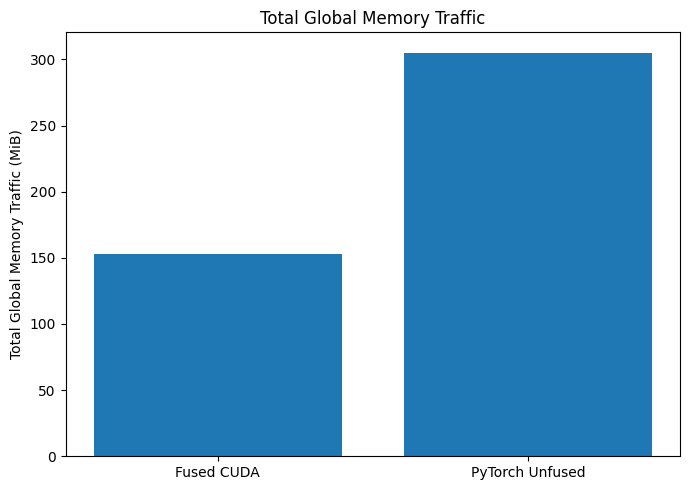

In [94]:
plot_df["Total Global MiB"] = (
    plot_df["Global Load Bytes"]
    + plot_df["Global Store Bytes"]
) / (1024 ** 2)


plt.figure(figsize=(7, 5))

plt.bar(
    plot_df["Implementation"],
    plot_df["Total Global MiB"]
)

plt.ylabel("Total Global Memory Traffic (MiB)")
plt.title("Total Global Memory Traffic")

plt.tight_layout()
plt.show()

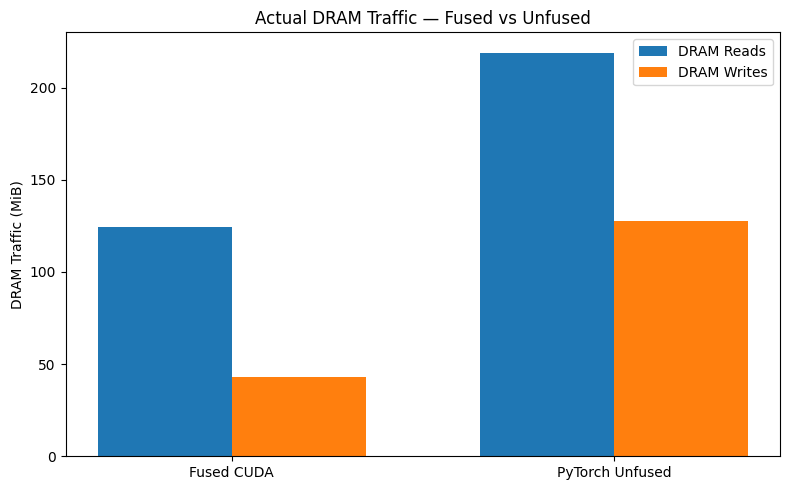

In [95]:
plot_df["DRAM Read MiB"] = (
    plot_df["DRAM Read Bytes"] / (1024 ** 2)
)

plot_df["DRAM Write MiB"] = (
    plot_df["DRAM Write Bytes"] / (1024 ** 2)
)


x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    plot_df["DRAM Read MiB"],
    width,
    label="DRAM Reads"
)

plt.bar(
    x + width/2,
    plot_df["DRAM Write MiB"],
    width,
    label="DRAM Writes"
)

plt.xticks(x, plot_df["Implementation"])
plt.ylabel("DRAM Traffic (MiB)")
plt.title("Actual DRAM Traffic — Fused vs Unfused")
plt.legend()

plt.tight_layout()
plt.show()

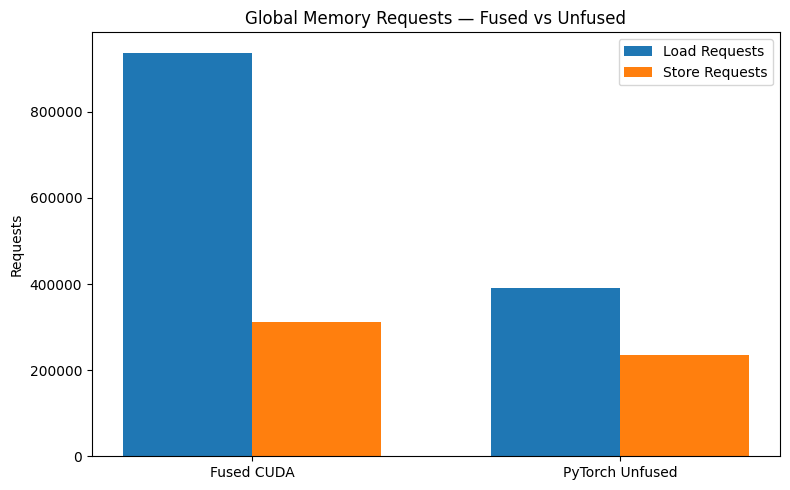

In [96]:
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    plot_df["Global Load Requests"],
    width,
    label="Load Requests"
)

plt.bar(
    x + width/2,
    plot_df["Global Store Requests"],
    width,
    label="Store Requests"
)

plt.xticks(x, plot_df["Implementation"])
plt.ylabel("Requests")
plt.title("Global Memory Requests — Fused vs Unfused")
plt.legend()

plt.tight_layout()
plt.show()

## Observations


- The fused CUDA kernel performed:
  - multiply
  - add
  - ReLU  
  inside a single CUDA kernel.



- The unfused PyTorch expression:
  `torch.relu(a * x + b)`
  was executed through multiple GPU kernels corresponding to:
  - multiplication
  - addition
  - ReLU/clamp



- For `N = 10,000,000` float32 elements, the fused kernel generated:
  - Global load traffic: ~120 MB
  - Global store traffic: ~40 MB
  - Total logical global-memory traffic: ~160 MB
  - Approximately ~153 MiB total



- The unfused PyTorch implementation generated:
  - Global load traffic: ~200 MB
  - Global store traffic: ~120 MB
  - Total logical global-memory traffic: ~320 MB
  - Approximately ~305 MiB total



- Therefore, fusion reduced total logical global-memory traffic by approximately **2×**.



- This matches the theoretical memory-traffic model exactly:
  - Fused CUDA:
    - 3 input reads: `a`, `x`, `b`
    - 1 output write: `y`
    - Total = 4N float transfers
  - Unfused PyTorch:
    - multiply: 2 reads + 1 write
    - add: 2 reads + 1 write
    - ReLU: 1 read + 1 write
    - Total = 8N float transfers



- For float32 values:
  - Fused traffic ≈ `4 × N × 4 bytes`
  - Unfused traffic ≈ `8 × N × 4 bytes`



- The measured NCU results therefore closely matched the expected theoretical traffic.



- Actual DRAM traffic was also substantially lower for the fused kernel.



- Approximate fused DRAM traffic:
  - DRAM reads: ~125 MiB
  - DRAM writes: ~43 MiB



- Approximate unfused PyTorch DRAM traffic:
  - DRAM reads: ~219 MiB
  - DRAM writes: ~128 MiB



- The reduction in DRAM traffic was not required to be exactly 2× because:
  - cache hits can satisfy some global-memory accesses
  - memory transactions can differ between kernels
  - PyTorch kernels may use different access patterns and vectorization



- An interesting result was that the fused CUDA kernel generated **more global-memory requests** than the unfused PyTorch implementation.



- This does not mean the fused implementation moved more data.



- Request count and transferred bytes are different metrics.



- PyTorch's optimized elementwise kernels may issue fewer, wider, or more efficiently coalesced memory requests.



- Therefore, for this experiment, **total bytes moved is a more useful fusion metric than raw memory-request count**.



- The main benefit of fusion was the elimination of intermediate tensors from global memory.



- In the unfused implementation, intermediate results had to be written to and later read back from global memory.



- In the fused implementation, intermediate values such as:
  `a[idx] * x[idx]`
  and
  `a[idx] * x[idx] + b[idx]`
  remained local to the thread, typically in registers, until the final result was written.



- This experiment demonstrated that kernel fusion is primarily valuable because it reduces unnecessary memory traffic and kernel-launch overhead.



### Core Takeaway



- Kernel fusion reduced logical global-memory traffic from approximately **305 MiB to 153 MiB**.
- This is approximately a **2× reduction**.
- The measured NCU result matched the theoretical traffic model.
- Fusion works by avoiding intermediate global-memory writes and reads between separate operations.
- Lower memory traffic does not necessarily imply fewer memory requests, because request size and memory-access efficiency also matter.